# Part 9 — Model Evaluation

This notebook evaluates the four trained HAM10000 classifiers on the **same fixed test set**:

1. Simple CNN
2. Complex CNN
3. ResNet18 Transfer Learning
4. ResNet18 Fine-Tuning

No model is retrained in this notebook. The best saved checkpoint from each previous experiment is loaded and evaluated once on `test.csv`.

**Primary comparison metric:** Macro F1, because HAM10000 is highly imbalanced.

Additional metrics:
- Accuracy
- Macro Precision / Recall / F1
- Weighted Precision / Recall / F1
- Multiclass ROC-AUC (One-vs-Rest)
- Per-class Precision / Recall / F1
- Confusion Matrix

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()

# Notebook is normally executed from /notebooks.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Deep Learning\skin-lesion-classification


In [2]:
import json
import random

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt

from src.models.simple_cnn import SimpleCNN
from src.models.complex_cnn import ComplexCNN
from src.models.transfer_learning import TransferLearningResNet18

from src.evaluation import (
    create_test_loader,
    evaluate_multiple_models,
    load_checkpoint,
    plot_confusion_matrix,
    plot_model_comparison,
    plot_multiclass_roc,
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.4.1+cpu
CUDA available: False


## 1. Reproducibility and device

Evaluation itself is deterministic because:
- `test_loader` uses `shuffle=False`
- no random augmentation is applied
- all models run in `eval()` mode

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Running on:", device)

Running on: cpu


## 2. Load evaluation configuration

In [4]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "evaluation.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg

{'seed': 42,
 'data': {'test_csv': 'data/processed/test.csv',
  'raw_dir': 'data/raw',
  'image_size': 224,
  'batch_size': 32,
  'num_workers': 0},
 'classes': {'class_to_idx': {'akiec': 0,
   'bcc': 1,
   'bkl': 2,
   'df': 3,
   'mel': 4,
   'nv': 5,
   'vasc': 6}},
 'models': {'simple_cnn': {'checkpoint': 'outputs/checkpoints/simple_cnn_best.pt'},
  'complex_cnn': {'checkpoint': 'outputs/checkpoints/complex_cnn_best.pt'},
  'transfer_resnet18': {'checkpoint': 'outputs/checkpoints/transfer_resnet18_best.pt'},
  'fine_tuned_resnet18': {'checkpoint': 'outputs/checkpoints/fine_tuned_resnet18_best.pt'}},
 'outputs': {'metrics_dir': 'outputs/metrics',
  'figures_dir': 'outputs/figures',
  'confusion_dir': 'outputs/confusion_matrices'}}

In [5]:
CLASS_TO_IDX = cfg["classes"]["class_to_idx"]

CLASS_NAMES = [
    name
    for name, idx in sorted(
        CLASS_TO_IDX.items(),
        key=lambda item: item[1],
    )
]

NUM_CLASSES = len(CLASS_NAMES)

print("CLASS_TO_IDX:", CLASS_TO_IDX)
print("CLASS_NAMES:", CLASS_NAMES)
print("NUM_CLASSES:", NUM_CLASSES)

CLASS_TO_IDX: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
CLASS_NAMES: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES: 7


## 3. Load the fixed test split

This must be the exact `test.csv` produced in Part 3.  
Do **not** resplit the data here.

In [6]:
TEST_CSV = PROJECT_ROOT / cfg["data"]["test_csv"]
RAW_DIR = PROJECT_ROOT / cfg["data"]["raw_dir"]

test_df = pd.read_csv(TEST_CSV)

print("Test images:", len(test_df))
print("Test lesions:", test_df["lesion_id"].nunique() if "lesion_id" in test_df.columns else "N/A")
display(test_df.head())

Test images: 1502
Test lesions: 1121


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,split
0,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,data/raw/HAM10000_images_part_1/ISIC_0029176.jpg,test
1,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,data/raw/HAM10000_images_part_1/ISIC_0029068.jpg,test
2,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,data/raw/HAM10000_images_part_1/ISIC_0025837.jpg,test
3,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,data/raw/HAM10000_images_part_1/ISIC_0025209.jpg,test
4,HAM_0007571,ISIC_0029836,bkl,histo,70.0,male,chest,data/raw/HAM10000_images_part_2/ISIC_0029836.jpg,test


In [7]:
print("Test class distribution:")
display(
    test_df["dx"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("dx")
    .to_frame("count")
)

Test class distribution:


,count
dx,
akiec,52
bcc,71
bkl,167
df,20
mel,167
nv,1004
vasc,21


## 4. Create one shared test DataLoader

All four models are evaluated using this exact same loader.
No augmentation is used on the test set.

In [8]:
test_loader = create_test_loader(
    test_df=test_df,
    data_root=RAW_DIR,
    class_to_idx=CLASS_TO_IDX,
    batch_size=int(cfg["data"].get("batch_size", 32)),
    num_workers=int(cfg["data"].get("num_workers", 0)),
    image_size=int(cfg["data"].get("image_size", 224)),
)

images, labels = next(iter(test_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Label range:", labels.min().item(), "->", labels.max().item())

Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])
Label range: 2 -> 2


## 5. Recreate model architectures

The architectures must match Parts 5–8 exactly.  
`pretrained=False` is intentional here: evaluation loads the saved project weights immediately, so ImageNet weights do not need to be downloaded again.

In [9]:
models = {
    "Simple CNN": SimpleCNN(
        num_classes=NUM_CLASSES,
        dropout=0.5,
    ),

    "Complex CNN": ComplexCNN(
        num_classes=NUM_CLASSES,
    ),

    "ResNet18 Transfer": TransferLearningResNet18(
        num_classes=NUM_CLASSES,
        dropout=0.3,
        pretrained=False,
        freeze_backbone=True,
    ),

    "ResNet18 Fine-Tuned": TransferLearningResNet18(
        num_classes=NUM_CLASSES,
        dropout=0.3,
        pretrained=False,
        freeze_backbone=False,
    ),
}

for name, model in models.items():
    print(name, "->", sum(p.numel() for p in model.parameters()), "parameters")

Simple CNN -> 619591 parameters
Complex CNN -> 2223847 parameters
ResNet18 Transfer -> 11309639 parameters
ResNet18 Fine-Tuned -> 11309639 parameters


## 6. Load the four best checkpoints

In [10]:
checkpoint_paths = {
    "Simple CNN":
        PROJECT_ROOT / cfg["models"]["simple_cnn"]["checkpoint"],

    "Complex CNN":
        PROJECT_ROOT / cfg["models"]["complex_cnn"]["checkpoint"],

    "ResNet18 Transfer":
        PROJECT_ROOT / cfg["models"]["transfer_resnet18"]["checkpoint"],

    "ResNet18 Fine-Tuned":
        PROJECT_ROOT / cfg["models"]["fine_tuned_resnet18"]["checkpoint"],
}

for name, path in checkpoint_paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

Simple CNN: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\simple_cnn_best.pt | exists=True
Complex CNN: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\complex_cnn_best.pt | exists=True
ResNet18 Transfer: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt | exists=True
ResNet18 Fine-Tuned: C:\Deep Learning\skin-lesion-classification\outputs\checkpoints\fine_tuned_resnet18_best.pt | exists=True


In [13]:
for model_name, checkpoint_path in checkpoint_paths.items():
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        elif "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    models[model_name].load_state_dict(state_dict)
    models[model_name].to(device)
    models[model_name].eval()

    print(f"Loaded: {model_name}")

Loaded: Simple CNN
Loaded: Complex CNN
Loaded: ResNet18 Transfer
Loaded: ResNet18 Fine-Tuned


## 7. Evaluate all models on the test set

Each model produces:
- `y_true`
- `y_pred`
- class probabilities
- aggregate metrics
- per-class report
- confusion matrix

In [14]:
comparison_df, results = evaluate_multiple_models(
    models=models,
    data_loader=test_loader,
    device=device,
    class_names=CLASS_NAMES,
)

Evaluating: Simple CNN
Evaluating: Complex CNN
Evaluating: ResNet18 Transfer
Evaluating: ResNet18 Fine-Tuned


## 8. Final model comparison

In [15]:
metric_columns = [
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "roc_auc_macro_ovr",
]

display(
    comparison_df[metric_columns]
    .style.format({
        col: "{:.4f}"
        for col in metric_columns
        if col != "model"
    })
)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr
0,ResNet18 Fine-Tuned,0.7690,0.6265,0.6222,0.6170,0.7813,0.7690,0.7726,0.9465
1,ResNet18 Transfer,0.7417,0.4636,0.4725,0.4626,0.7254,0.7417,0.7321,0.9034
2,Complex CNN,0.7237,0.4538,0.4433,0.4396,0.7107,0.7237,0.7132,0.8701
3,Simple CNN,0.6005,0.4265,0.4918,0.4278,0.7340,0.6005,0.6392,0.8839


In [16]:
best_model_name = comparison_df.iloc[0]["model"]
best_macro_f1 = comparison_df.iloc[0]["f1_macro"]

print("Best model by Macro F1:", best_model_name)
print(f"Macro F1: {best_macro_f1:.4f}")

Best model by Macro F1: ResNet18 Fine-Tuned
Macro F1: 0.6170


### Why Macro F1 is the primary metric

Accuracy alone can be misleading on HAM10000 because the dataset is strongly imbalanced, especially because the `nv` class is much larger than several minority classes.

Macro F1 computes F1 independently for every diagnostic class and then gives each class equal weight. Therefore, it is more appropriate for judging whether a model performs consistently across common and rare lesion classes.

## 9. Comparison plots

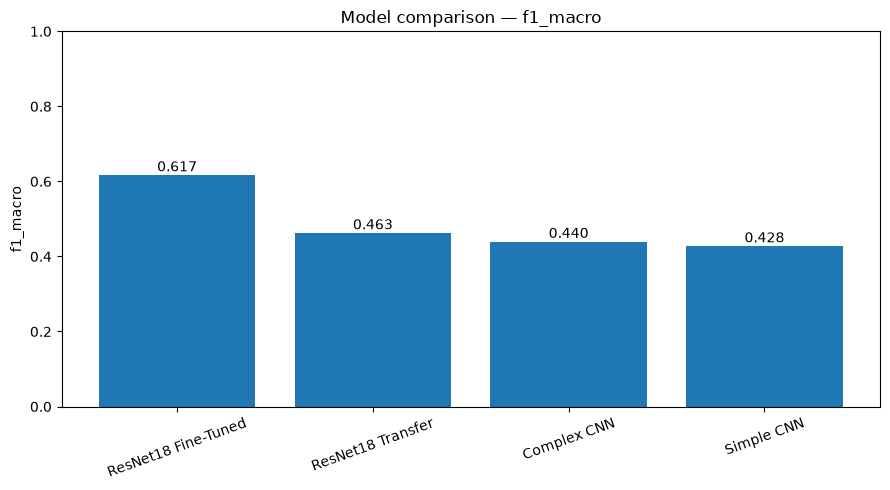

In [17]:
fig, ax = plot_model_comparison(
    comparison_df,
    metric="f1_macro",
)
plt.show()

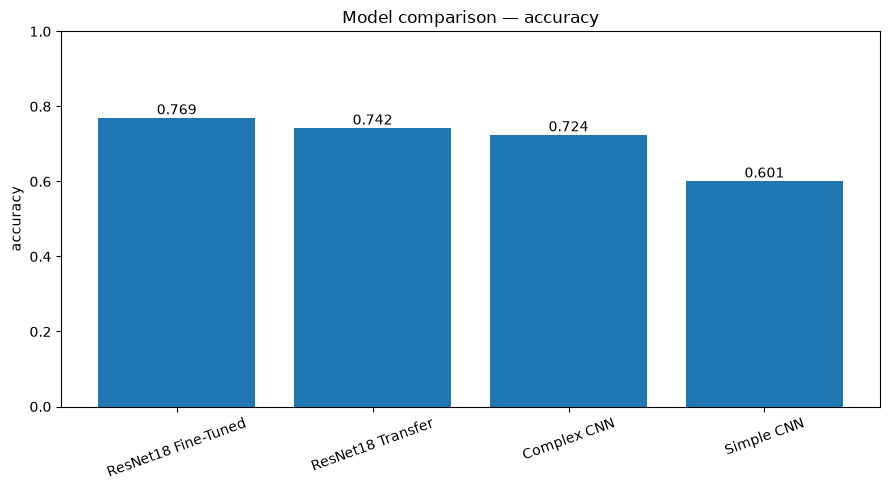

In [18]:
fig, ax = plot_model_comparison(
    comparison_df,
    metric="accuracy",
)
plt.show()

## 10. Per-class classification reports

In [19]:
for model_name, result in results.items():
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    display(
        result["classification_report"]
        .loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
        .style.format({
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        })
    )


Simple CNN


,precision,recall,f1-score,support
akiec,0.2602,0.6154,0.3657,52
bcc,0.2824,0.3380,0.3077,71
bkl,0.3575,0.4731,0.4072,167
df,0.3750,0.1500,0.2143,20
mel,0.2899,0.5988,0.3906,167
nv,0.9394,0.6484,0.7672,1004
vasc,0.4815,0.6190,0.5417,21



Complex CNN


,precision,recall,f1-score,support
akiec,0.4848,0.3077,0.3765,52
bcc,0.3419,0.5634,0.4255,71
bkl,0.4437,0.4012,0.4214,167
df,0.0000,0.0000,0.0000,20
mel,0.4649,0.3174,0.3772,167
nv,0.8504,0.8944,0.8718,1004
vasc,0.5909,0.6190,0.6047,21



ResNet18 Transfer


,precision,recall,f1-score,support
akiec,0.5143,0.3462,0.4138,52
bcc,0.5060,0.5915,0.5455,71
bkl,0.4865,0.4311,0.4571,167
df,0.0000,0.0000,0.0000,20
mel,0.4465,0.4251,0.4356,167
nv,0.8585,0.8944,0.8761,1004
vasc,0.4333,0.6190,0.5098,21



ResNet18 Fine-Tuned


,precision,recall,f1-score,support
akiec,0.4789,0.6538,0.5528,52
bcc,0.6351,0.6620,0.6483,71
bkl,0.5970,0.4790,0.5316,167
df,0.6154,0.4000,0.4848,20
mel,0.4465,0.5749,0.5026,167
nv,0.8984,0.8715,0.8847,1004
vasc,0.7143,0.7143,0.7143,21


## 11. Confusion matrices

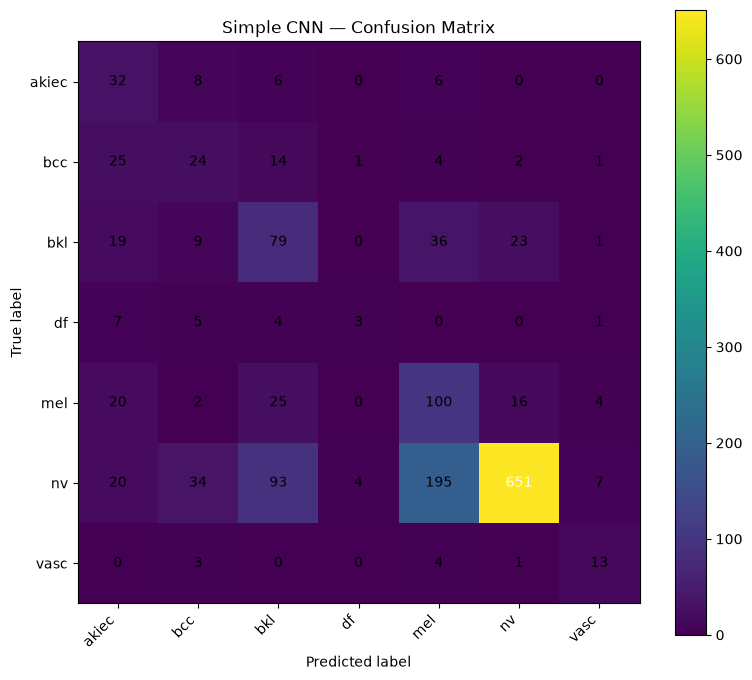

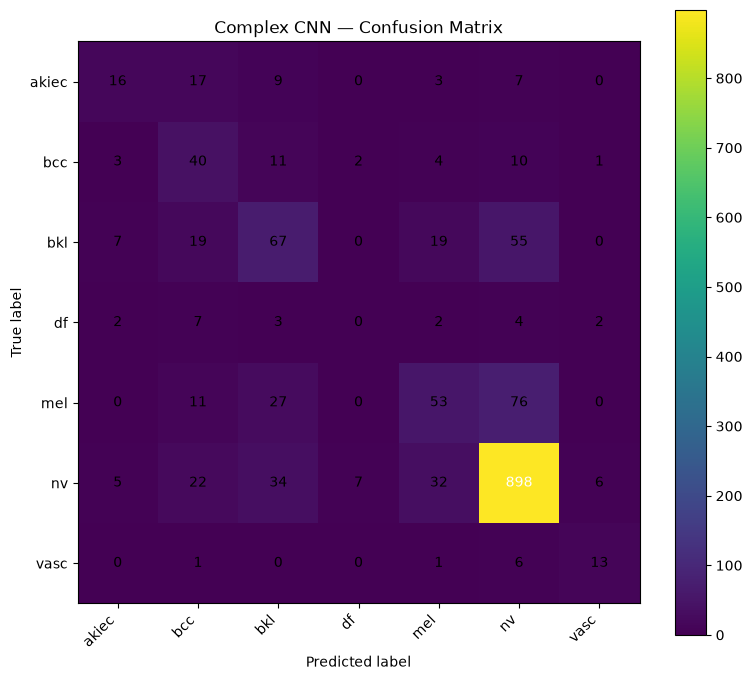

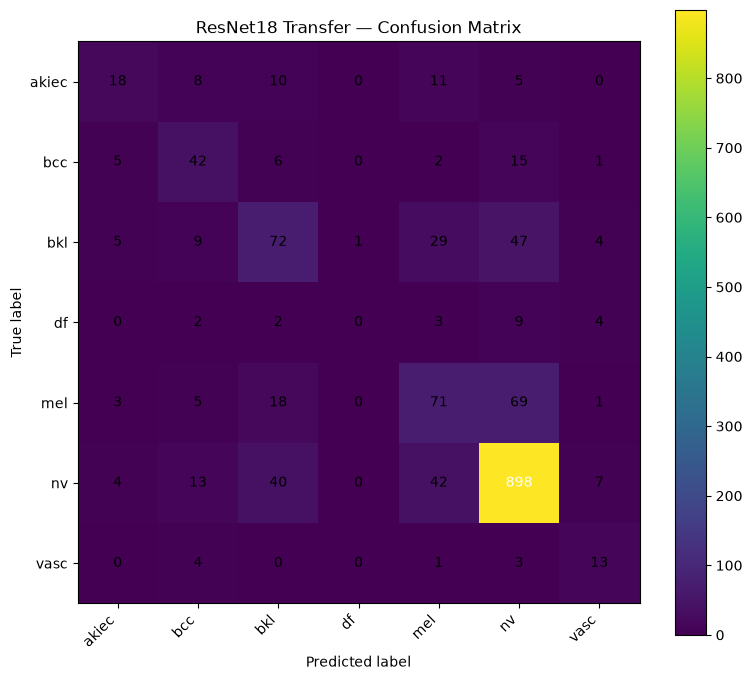

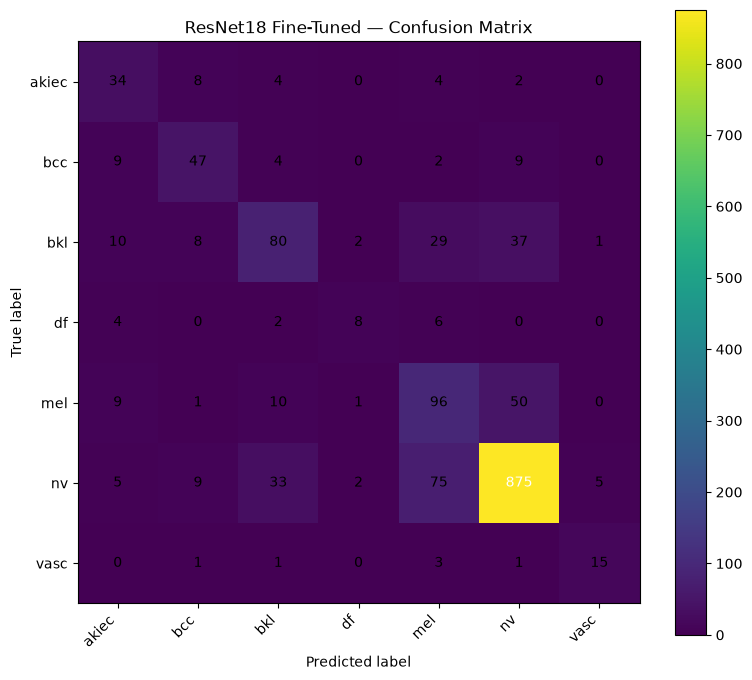

In [20]:
for model_name, result in results.items():
    plot_confusion_matrix(
        result["confusion_matrix"],
        CLASS_NAMES,
        title=f"{model_name} — Confusion Matrix",
    )
    plt.show()

## 12. ROC curves

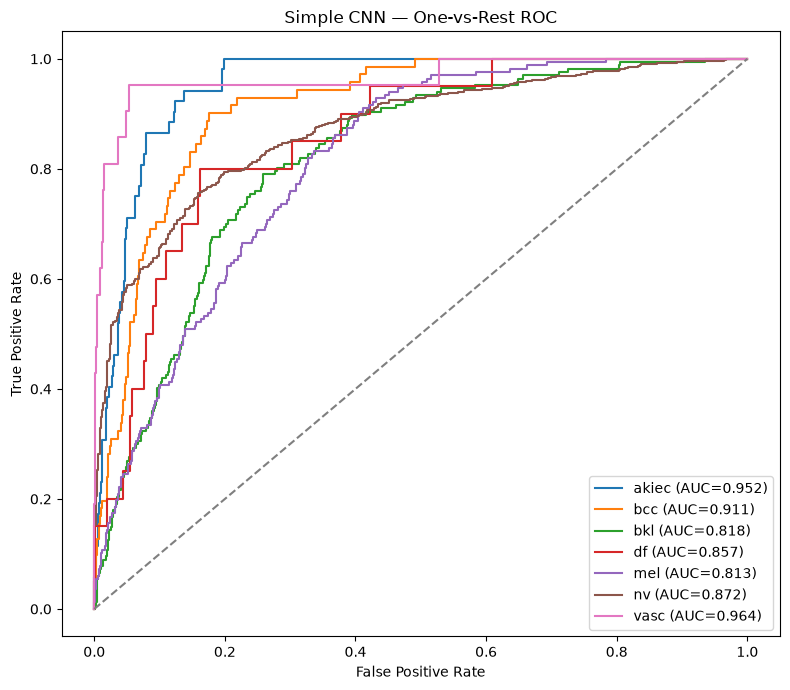

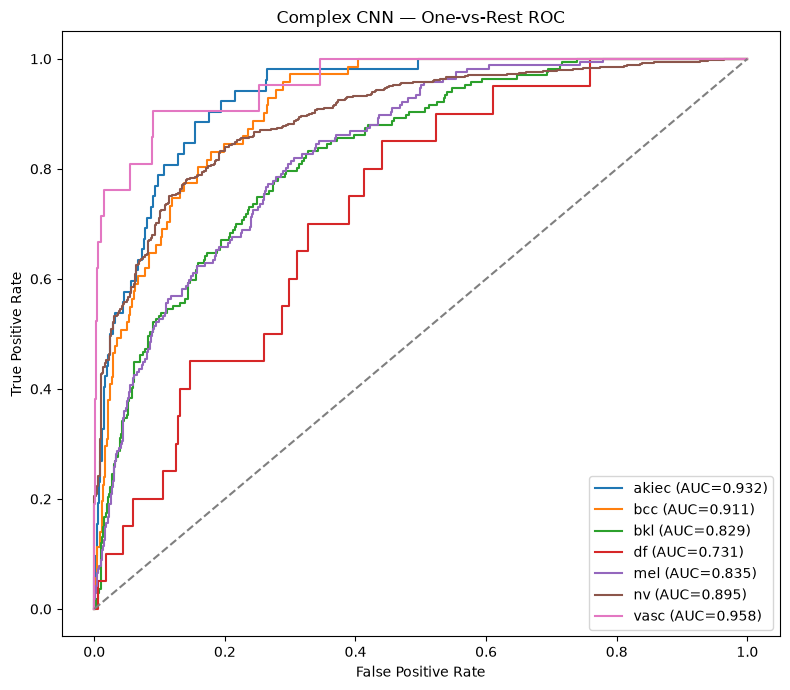

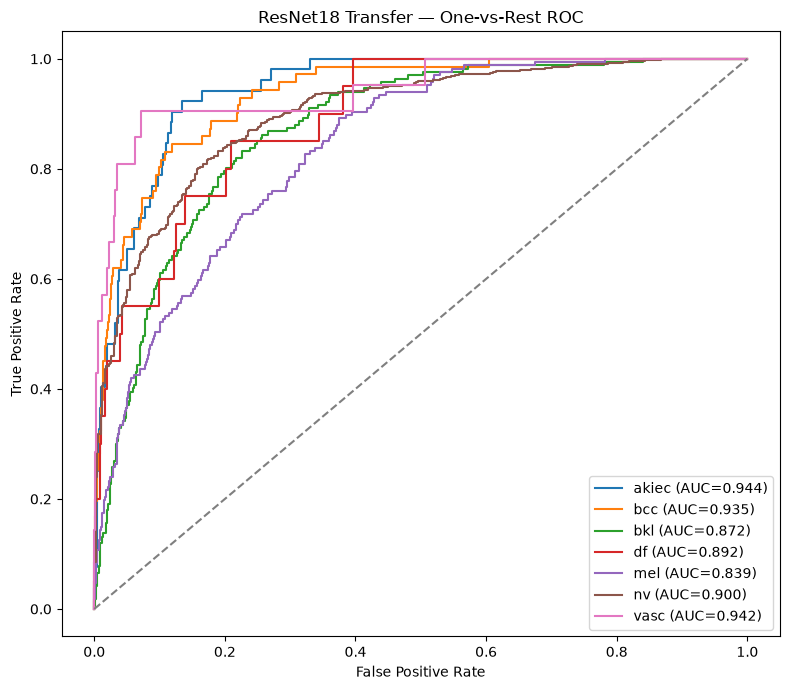

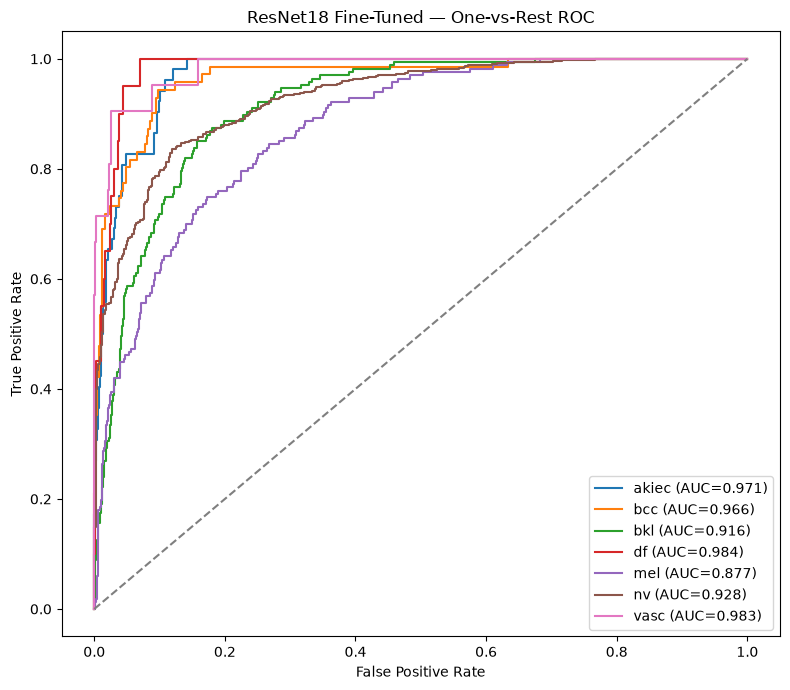

In [21]:
for model_name, result in results.items():
    plot_multiclass_roc(
        y_true=result["y_true"],
        y_prob=result["y_prob"],
        class_names=CLASS_NAMES,
        title=f"{model_name} — One-vs-Rest ROC",
    )
    plt.show()

## 13. Save evaluation outputs

The notebook saves:
- final model-comparison CSV
- one JSON metrics file per model
- one classification-report CSV per model
- one prediction CSV per model
- confusion-matrix figures
- ROC figures
- final Macro-F1 and Accuracy comparison charts

These files can be used directly in Part 10 Error Analysis and in the final report.

In [22]:
METRICS_DIR = PROJECT_ROOT / cfg["outputs"]["metrics_dir"]
FIGURES_DIR = PROJECT_ROOT / cfg["outputs"]["figures_dir"]
CONFUSION_DIR = PROJECT_ROOT / cfg["outputs"]["confusion_dir"]

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(
    METRICS_DIR / "model_comparison.csv",
    index=False,
)

for model_name, result in results.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    result["classification_report"].to_csv(
        METRICS_DIR / f"{safe_name}_classification_report.csv"
    )

    predictions_df = test_df[["image_id", "dx"]].copy()
    predictions_df["true_idx"] = result["y_true"]
    predictions_df["pred_idx"] = result["y_pred"]
    predictions_df["pred_dx"] = [
        CLASS_NAMES[i]
        for i in result["y_pred"]
    ]
    predictions_df["correct"] = (
        predictions_df["true_idx"]
        == predictions_df["pred_idx"]
    )

    predictions_df.to_csv(
        METRICS_DIR / f"{safe_name}_test_predictions.csv",
        index=False,
    )

    with open(
        METRICS_DIR / f"{safe_name}_metrics.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                key: (
                    None
                    if pd.isna(value)
                    else float(value)
                )
                for key, value in result["metrics"].items()
            },
            f,
            indent=2,
        )

    fig, _ = plot_confusion_matrix(
        result["confusion_matrix"],
        CLASS_NAMES,
        title=f"{model_name} — Confusion Matrix",
        save_path=CONFUSION_DIR / f"{safe_name}_confusion_matrix.png",
    )
    plt.close(fig)

    fig, _ = plot_multiclass_roc(
        result["y_true"],
        result["y_prob"],
        CLASS_NAMES,
        title=f"{model_name} — One-vs-Rest ROC",
        save_path=FIGURES_DIR / f"{safe_name}_roc.png",
    )
    plt.close(fig)

fig, _ = plot_model_comparison(
    comparison_df,
    metric="f1_macro",
    save_path=FIGURES_DIR / "model_comparison_macro_f1.png",
)
plt.close(fig)

fig, _ = plot_model_comparison(
    comparison_df,
    metric="accuracy",
    save_path=FIGURES_DIR / "model_comparison_accuracy.png",
)
plt.close(fig)

print("Evaluation outputs saved successfully.")

Evaluation outputs saved successfully.


## 14. Final conclusion template

After running the notebook, report the model with the highest **Macro F1** as the strongest overall model, but discuss its class-level recall/F1 and confusion matrix as well.

Do not select a model only because it has the highest accuracy. For HAM10000, minority-class performance is especially important because of class imbalance.